In [4]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Plot styling
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 12
sns.set_style("whitegrid")

print("Libraries loaded!")

Libraries loaded!


In [5]:
# Load the data
orders = pd.read_csv('../data/raw/Orders_and_shipments.csv', 
                     encoding='latin-1', skipinitialspace=True)
inventory = pd.read_csv('../data/raw/Inventory.csv', 
                        encoding='latin-1', skipinitialspace=True)
fulfillment = pd.read_csv('../data/raw/Fulfillment.csv', 
                          encoding='latin-1', skipinitialspace=True)

# Clean column names
orders.columns = orders.columns.str.strip()
inventory.columns = inventory.columns.str.strip()
fulfillment.columns = fulfillment.columns.str.strip()

# Clean Discount % column
orders['Discount %'] = pd.to_numeric(orders['Discount %'].replace(' - ', 0), errors='coerce').fillna(0)

print(f" Data loaded!")
print(f"   Orders: {len(orders):,} rows")
print(f"   Inventory: {len(inventory):,} rows")
print(f"   Fulfillment: {len(fulfillment):,} rows")

 Data loaded!
   Orders: 30,871 rows
   Inventory: 4,200 rows
   Fulfillment: 118 rows


In [6]:
# ================================================
# KPI CALCULATIONS
# ================================================

# 1. Overall Profit Margin %
total_revenue = orders['Gross Sales'].sum()
total_profit = orders['Profit'].sum()
profit_margin = (total_profit / total_revenue) * 100

# 2. Average Order Processing Time (days)
avg_processing_time = orders['Shipment Days - Scheduled'].mean()

# 3. Perfect Order Rate % (orders with no delay)
perfect_orders = (orders['Shipment Days - Scheduled'] <= 0).sum()
perfect_order_rate = (perfect_orders / len(orders)) * 100

# 4. Delay Rate %
delayed_orders = (orders['Shipment Days - Scheduled'] > 0).sum()
delay_rate = (delayed_orders / len(orders)) * 100

# 5. Average Inventory Carrying Cost per product
inventory['Storage Cost'] = inventory['Warehouse Inventory'] * inventory['Inventory Cost Per Unit']
avg_storage_cost = inventory['Storage Cost'].mean()
total_storage_cost = inventory['Storage Cost'].sum()

# 6. Inventory to Sales Delta (overstock indicator)
total_inventory = inventory['Warehouse Inventory'].sum()
total_orders_qty = orders['Order Quantity'].sum()
inventory_delta = total_inventory - total_orders_qty

# Print KPI Scorecard
print("=" * 45)
print("   SUPPLY CHAIN KPI SCORECARD")
print("=" * 45)
print(f"   Profit Margin:          {profit_margin:.2f}%")
print(f"   Avg Processing Time:    {avg_processing_time:.2f} days")
print(f"   Perfect Order Rate:     {perfect_order_rate:.2f}%")
print(f"   Delay Rate:             {delay_rate:.2f}%")
print(f"   Total Storage Cost:     ${total_storage_cost:,.2f}")
print(f"   Inventory-Sales Delta:  {inventory_delta:,} units")
print("=" * 45)

   SUPPLY CHAIN KPI SCORECARD
   Profit Margin:          64.62%
   Avg Processing Time:    3.07 days
   Perfect Order Rate:     0.00%
   Delay Rate:             100.00%
   Total Storage Cost:     $86,430.92
   Inventory-Sales Delta:  4,647 units


In [7]:
# Fix the Shipment Days column - it uses an em dash in the column name
# Renaming it to something clean
orders.rename(columns={'Shipment Days - Scheduled': 'Shipment_Delay'}, inplace=True)

# Check the actual values
print("Sample values:", orders['Shipment_Delay'].head(10).tolist())
print("Data type:", orders['Shipment_Delay'].dtype)
print("Min:", orders['Shipment_Delay'].min())
print("Max:", orders['Shipment_Delay'].max())
print("Negative values (early):", (orders['Shipment_Delay'] < 0).sum())
print("Zero values (on time):", (orders['Shipment_Delay'] == 0).sum())
print("Positive values (delayed):", (orders['Shipment_Delay'] > 0).sum())

Sample values: [4, 4, 4, 4, 4, 4, 4, 4, 4, 4]
Data type: int64
Min: 1
Max: 4
Negative values (early): 0
Zero values (on time): 0
Positive values (delayed): 30871


In [8]:
# ================================================
# CORRECTED KPI SCORECARD
# ================================================

# The dataset shows ALL orders have delays (1-4 days)
# This IS the insight - 100% delay rate is a finding!

# Delay breakdown
delay_1 = (orders['Shipment_Delay'] == 1).sum()
delay_2 = (orders['Shipment_Delay'] == 2).sum()
delay_3 = (orders['Shipment_Delay'] == 3).sum()
delay_4 = (orders['Shipment_Delay'] == 4).sum()

# Recalculate KPIs correctly
avg_delay = orders['Shipment_Delay'].mean()
total_orders = len(orders)
total_revenue = orders['Gross Sales'].sum()
total_profit = orders['Profit'].sum()
profit_margin = (total_profit / total_revenue) * 100
total_storage_cost = inventory['Storage Cost'].sum()
inventory_delta = inventory['Warehouse Inventory'].sum() - orders['Order Quantity'].sum()

print("=" * 50)
print("     SUPPLY CHAIN KPI SCORECARD")
print("=" * 50)
print(f"   Profit Margin:           {profit_margin:.2f}%")
print(f"   Total Orders:            {total_orders:,}")
print(f"   Avg Shipment Delay:      {avg_delay:.2f} days")
print(f"   Orders Delayed 1 day:    {delay_1:,} ({delay_1/total_orders*100:.1f}%)")
print(f"   Orders Delayed 2 days:   {delay_2:,} ({delay_2/total_orders*100:.1f}%)")
print(f"   Orders Delayed 3 days:   {delay_3:,} ({delay_3/total_orders*100:.1f}%)")
print(f"   Orders Delayed 4 days:   {delay_4:,} ({delay_4/total_orders*100:.1f}%)")
print(f"   Total Storage Cost:      ${total_storage_cost:,.2f}")
print(f"   Inventory Surplus:       {inventory_delta:,} units")
print("=" * 50)
print("\n  KEY FINDING: 100% of orders experience")
print("   shipment delays ranging from 1 to 4 days.")
print("   Immediate investigation recommended.")

     SUPPLY CHAIN KPI SCORECARD
   Profit Margin:           64.62%
   Total Orders:            30,871
   Avg Shipment Delay:      3.07 days
   Orders Delayed 1 day:    4,859 (15.7%)
   Orders Delayed 2 days:   6,038 (19.6%)
   Orders Delayed 3 days:   1,980 (6.4%)
   Orders Delayed 4 days:   17,994 (58.3%)
   Total Storage Cost:      $86,430.92
   Inventory Surplus:       4,647 units

  KEY FINDING: 100% of orders experience
   shipment delays ranging from 1 to 4 days.
   Immediate investigation recommended.


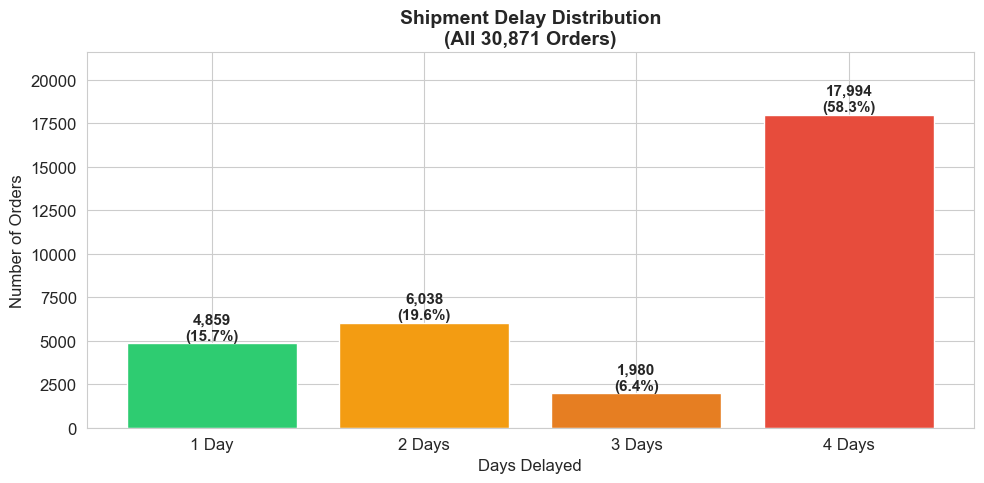

 Chart 1 saved!


In [9]:
# ================================================
# CHART 1 - Shipment Delay Distribution
# ================================================

delay_counts = orders['Shipment_Delay'].value_counts().sort_index()

plt.figure(figsize=(10, 5))
bars = plt.bar(delay_counts.index, delay_counts.values, 
               color=['#2ecc71', '#f39c12', '#e67e22', '#e74c3c'])

# Add value labels on bars
for bar, val in zip(bars, delay_counts.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
             f'{val:,}\n({val/total_orders*100:.1f}%)', 
             ha='center', fontsize=11, fontweight='bold')

plt.title('Shipment Delay Distribution\n(All 30,871 Orders)', fontsize=14, fontweight='bold')
plt.xlabel('Days Delayed', fontsize=12)
plt.ylabel('Number of Orders', fontsize=12)
plt.xticks([1, 2, 3, 4], ['1 Day', '2 Days', '3 Days', '4 Days'])
plt.ylim(0, delay_counts.max() * 1.2)
plt.tight_layout()
plt.savefig('../reports/chart1_shipment_delay.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Chart 1 saved!")

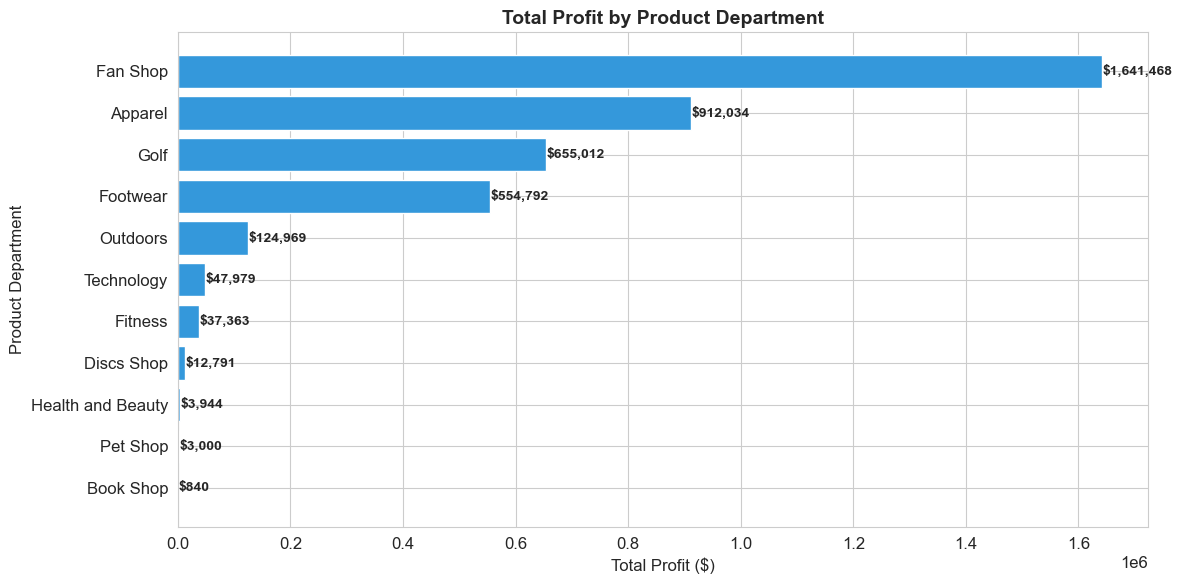

 Chart 2 saved!


In [11]:
# ================================================
# CHART 2 - Profit by Product Department
# ================================================

dept_profit = orders.groupby('Product Department')['Profit'].sum().sort_values(ascending=True)

plt.figure(figsize=(12, 6))
colors = ['#e74c3c' if x < 0 else '#3498db' for x in dept_profit.values]
bars = plt.barh(dept_profit.index, dept_profit.values, color=colors)

# Add value labels
for bar, val in zip(bars, dept_profit.values):
    plt.text(val + 500, bar.get_y() + bar.get_height()/2,
             f'${val:,.0f}', va='center', fontsize=10, fontweight='bold')

plt.title('Total Profit by Product Department', fontsize=14, fontweight='bold')
plt.xlabel('Total Profit ($)', fontsize=12)
plt.ylabel('Product Department', fontsize=12)
plt.tight_layout()
plt.savefig('../reports/chart2_profit_by_department.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Chart 2 saved!")

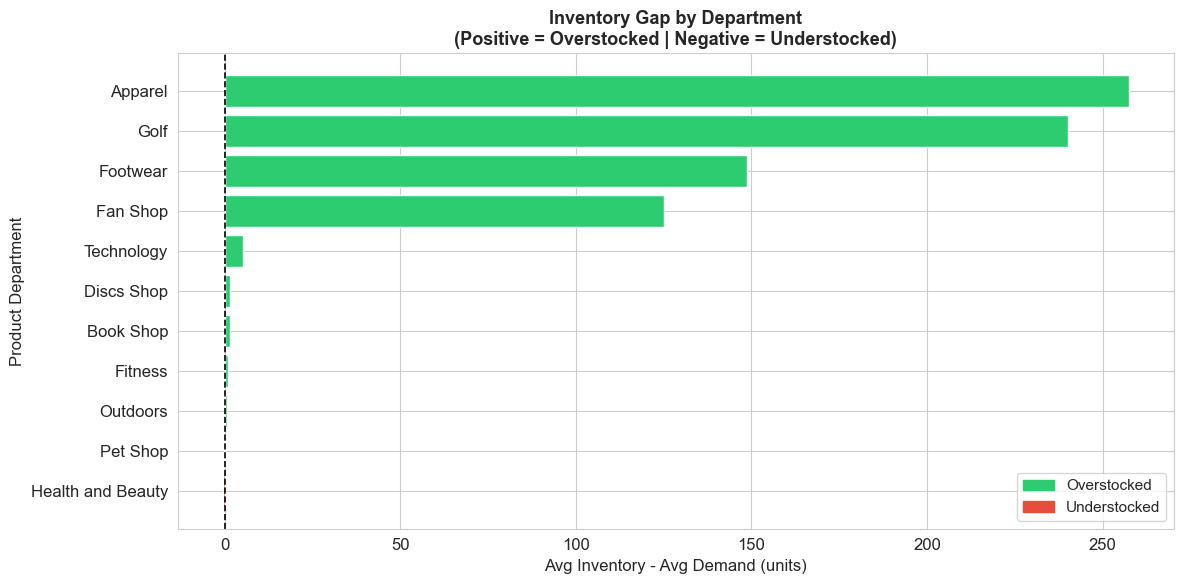

 Chart 3 saved!


In [12]:
# ================================================
# CHART 3 - Overstock vs Understock by Department
# ================================================

# Merge orders and inventory
merged = orders.merge(inventory, on='Product Name', how='left')

# Calculate supply vs demand per department
stock_status = merged.groupby('Product Department').agg(
    avg_inventory=('Warehouse Inventory', 'mean'),
    avg_demand=('Order Quantity', 'mean')
).reset_index()

stock_status['gap'] = stock_status['avg_inventory'] - stock_status['avg_demand']
stock_status['status'] = stock_status['gap'].apply(
    lambda x: 'Overstocked' if x > 0 else 'Understocked'
)
stock_status = stock_status.sort_values('gap', ascending=True)

plt.figure(figsize=(12, 6))
colors = ['#e74c3c' if x < 0 else '#2ecc71' for x in stock_status['gap']]
bars = plt.barh(stock_status['Product Department'], stock_status['gap'], color=colors)

plt.axvline(x=0, color='black', linewidth=1.2, linestyle='--')
plt.title('Inventory Gap by Department\n(Positive = Overstocked | Negative = Understocked)',
          fontsize=13, fontweight='bold')
plt.xlabel('Avg Inventory - Avg Demand (units)', fontsize=12)
plt.ylabel('Product Department', fontsize=12)

# Legend
from matplotlib.patches import Patch
legend = [Patch(color='#2ecc71', label='Overstocked'),
          Patch(color='#e74c3c', label='Understocked')]
plt.legend(handles=legend, fontsize=11)

plt.tight_layout()
plt.savefig('../reports/chart3_stock_status.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Chart 3 saved!")

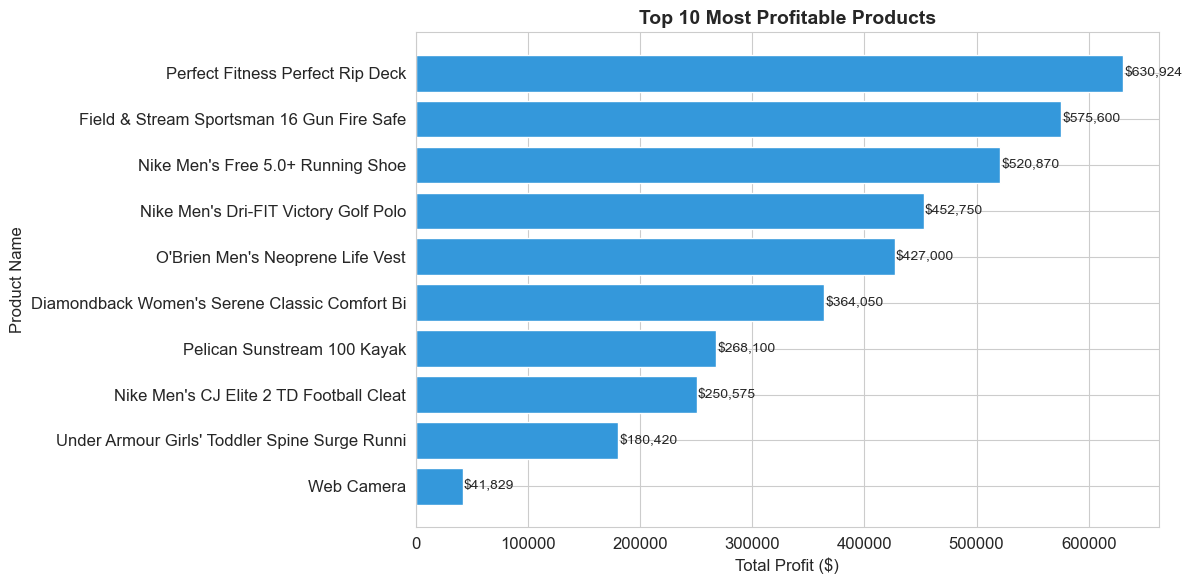

Chart 4 saved.


In [13]:
# ================================================
# CHART 4 - Top 10 Most Profitable Products
# ================================================

top_products = orders.groupby('Product Name')['Profit'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(12, 6))
bars = plt.barh(top_products.index[::-1], top_products.values[::-1], color='#3498db')

for bar, val in zip(bars, top_products.values[::-1]):
    plt.text(val + 1000, bar.get_y() + bar.get_height()/2,
             f'${val:,.0f}', va='center', fontsize=10)

plt.title('Top 10 Most Profitable Products', fontsize=14, fontweight='bold')
plt.xlabel('Total Profit ($)', fontsize=12)
plt.ylabel('Product Name', fontsize=12)
plt.tight_layout()
plt.savefig('../reports/chart4_top_products.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 4 saved.")

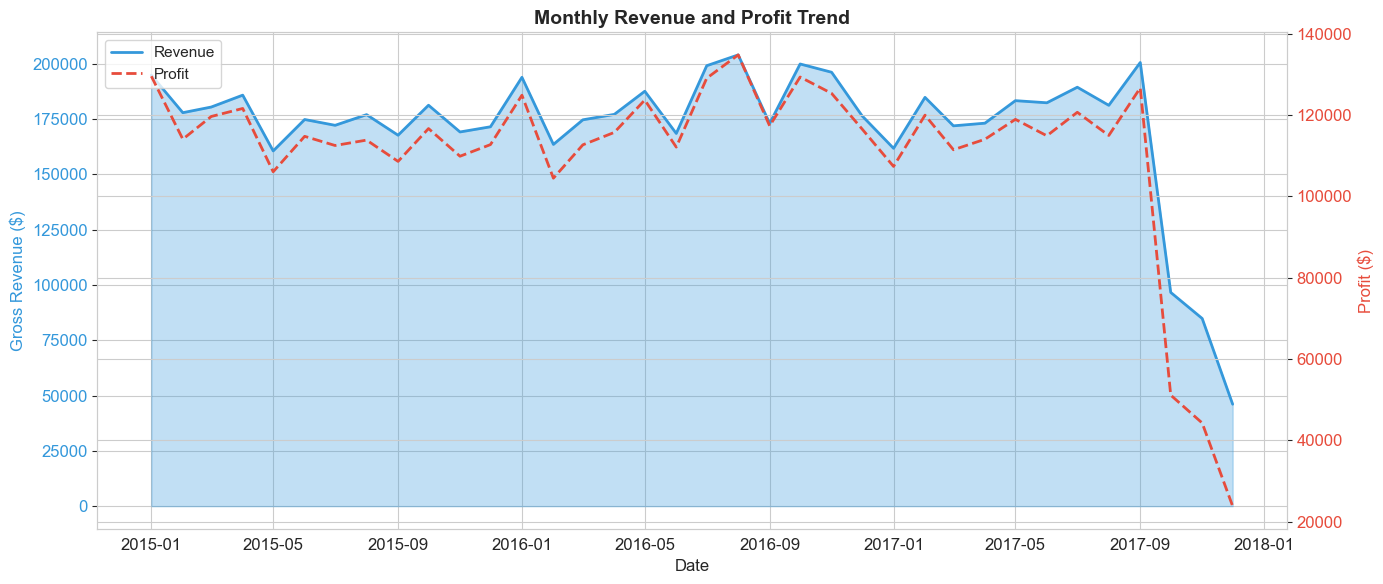

Chart 5 saved.


In [14]:
# ================================================
# CHART 5 - Monthly Revenue Trend
# ================================================

monthly = orders.groupby(['Order Year', 'Order Month']).agg(
    revenue=('Gross Sales', 'sum'),
    profit=('Profit', 'sum'),
    order_count=('Order ID', 'count')
).reset_index()

monthly['date'] = pd.to_datetime(
    monthly['Order Year'].astype(str) + '-' + monthly['Order Month'].astype(str)
)
monthly = monthly.sort_values('date')

fig, ax1 = plt.subplots(figsize=(14, 6))

ax1.fill_between(monthly['date'], monthly['revenue'], alpha=0.3, color='#3498db')
ax1.plot(monthly['date'], monthly['revenue'], color='#3498db', linewidth=2, label='Revenue')
ax1.set_xlabel('Date', fontsize=12)
ax1.set_ylabel('Gross Revenue ($)', fontsize=12, color='#3498db')
ax1.tick_params(axis='y', labelcolor='#3498db')

ax2 = ax1.twinx()
ax2.plot(monthly['date'], monthly['profit'], color='#e74c3c', linewidth=2, 
         linestyle='--', label='Profit')
ax2.set_ylabel('Profit ($)', fontsize=12, color='#e74c3c')
ax2.tick_params(axis='y', labelcolor='#e74c3c')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=11)

plt.title('Monthly Revenue and Profit Trend', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/chart5_monthly_trend.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 5 saved.")